## Superstore Sales Analysis

#### Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#### Load Dataset and Data Exploration

In [2]:
df = pd.read_csv('SampleSuperstore.csv')
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [4]:
# Display initial info
print("Initial Dataset Shape:", df.shape)

Initial Dataset Shape: (9994, 13)


#### Data Cleaning Steps

In [8]:
#Check for missing values
print("Missing Values per Column:\n", df.isnull().sum())

Missing Values per Column:
 Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


In [9]:
# Handle missing values (drop or fill)
df = df.dropna() # Dropping rows with missing data

In [10]:
# Remove duplicates
df = df.drop_duplicates()
print("\nDataset Shape after removing duplicates:", df.shape)


Dataset Shape after removing duplicates: (9977, 13)


In [12]:
# Use NumPy for numerical cleaning & transformation

# Handling negative or unrealistic values
sales_array = np.array(df['Sales'])
quantity_array = np.array(df['Quantity'])

In [13]:
# Replace negative sales (if any) with mean sales
mean_sales = np.mean(sales_array[sales_array > 0])
sales_array = np.where(sales_array < 0, mean_sales, sales_array)
df['Sales'] = sales_array

In [14]:
# Add calculated columns using NumPy
profit_array = np.array(df['Profit'])

In [15]:
#Profit Margin Calculation
df['Profit Margin (%)'] = np.round((profit_array / sales_array) * 100, 2)

In [16]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Profit Margin (%)
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,16.00
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,30.00
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,47.00
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,-40.00
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,11.25


In [17]:
print(df.info())
print(df.describe())
print("\nUnique Regions:", df['Region'].unique())
print("Unique Categories:", df['Category'].unique())

<class 'pandas.core.frame.DataFrame'>
Index: 9977 entries, 0 to 9993
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Ship Mode          9977 non-null   object 
 1   Segment            9977 non-null   object 
 2   Country            9977 non-null   object 
 3   City               9977 non-null   object 
 4   State              9977 non-null   object 
 5   Postal Code        9977 non-null   int64  
 6   Region             9977 non-null   object 
 7   Category           9977 non-null   object 
 8   Sub-Category       9977 non-null   object 
 9   Sales              9977 non-null   float64
 10  Quantity           9977 non-null   int64  
 11  Discount           9977 non-null   float64
 12  Profit             9977 non-null   float64
 13  Profit Margin (%)  9977 non-null   float64
dtypes: float64(4), int64(2), object(8)
memory usage: 1.1+ MB
None
        Postal Code         Sales     Quantity     Discount    

#### Analysis

In [18]:
# Overall Sales Metrics

total_sales = np.sum(df['Sales'])
total_profit = np.sum(df['Profit'])
avg_sales = np.mean(df['Sales'])
avg_profit = np.mean(df['Profit'])
total_quantity = np.sum(df['Quantity'])

In [19]:
print("===== Overall Metrics =====")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Average Sale per Transaction: ${avg_sales:,.2f}")
print(f"Average Profit per Transaction: ${avg_profit:,.2f}")
print(f"Total Quantity Sold: {total_quantity}")

===== Overall Metrics =====
Total Sales: $2,296,195.59
Total Profit: $286,241.42
Average Sale per Transaction: $230.15
Average Profit per Transaction: $28.69
Total Quantity Sold: 37820


In [20]:
# 2. Regional Performance Analysis

region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print("\n===== Regional Sales =====\n", region_sales)
print("\n===== Regional Profit =====\n", region_profit)


===== Regional Sales =====
 Region
West       725255.6365
East       678435.1960
Central    500782.8528
South      391721.9050
Name: Sales, dtype: float64

===== Regional Profit =====
 Region
West       108329.8079
East        91506.3092
South       46749.4303
Central     39655.8752
Name: Profit, dtype: float64


In [21]:
# Identify top-performing region
top_region = region_sales.idxmax()
print(f"\nTop Performing Region (by Sales): {top_region}")


Top Performing Region (by Sales): West


In [22]:
# Category-wise and Segment-wise Analysis
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)


print("\n===== Category Sales =====\n", category_sales)
print("\n===== Segment Sales =====\n", segment_sales)


===== Category Sales =====
 Category
Technology         836154.0330
Furniture          741306.3133
Office Supplies    718735.2440
Name: Sales, dtype: float64

===== Segment Sales =====
 Segment
Consumer       1.160833e+06
Corporate      7.060701e+05
Home Office    4.292927e+05
Name: Sales, dtype: float64


In [24]:
# Profitability Analysis

df['Profit Margin (%)'] = np.round((df['Profit'] / df['Sales']) * 100, 2)
avg_profit_margin = np.mean(df['Profit Margin (%)'])

print(f"\nAverage Profit Margin: {avg_profit_margin:.2f}%")


Average Profit Margin: 12.01%


In [27]:
# Identify most profitable categories
profit_by_category = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print("\n===== Profit by Category =====\n", profit_by_category)


===== Profit by Category =====
 Category
Technology         145454.9481
Office Supplies    122364.6608
Furniture           18421.8137
Name: Profit, dtype: float64


In [28]:
# Correlation Analysis
correlation = df[['Sales', 'Profit', 'Quantity', 'Discount']].corr()
print("\n===== Correlation Matrix =====\n", correlation)


===== Correlation Matrix =====
              Sales    Profit  Quantity  Discount
Sales     1.000000  0.479067  0.200722 -0.028311
Profit    0.479067  1.000000  0.066211 -0.219662
Quantity  0.200722  0.066211  1.000000  0.008678
Discount -0.028311 -0.219662  0.008678  1.000000


#### Data Visualization

In [34]:
# Ensure numerical columns are correct type
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Profit Margin (%)']
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

C:\Users\anu52\AppData\Local\Temp\ipykernel_20468\314138376.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.index, y=region_sales.values, palette='viridis')


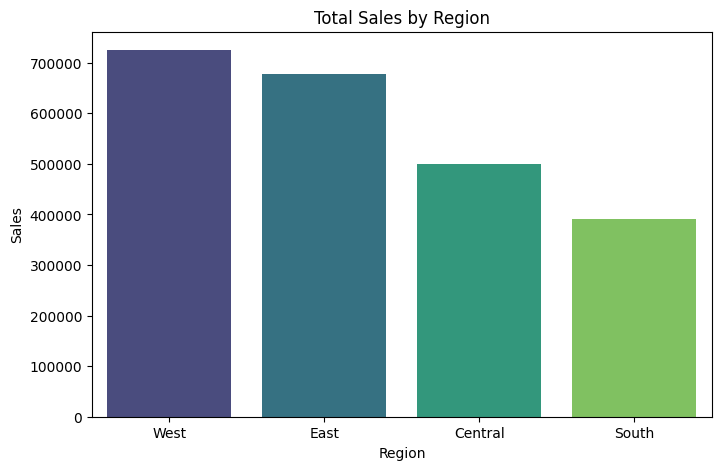

In [29]:
# Sales by Region - Bar Plot
# -----------------------------
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=region_sales.index, y=region_sales.values, palette='viridis')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()

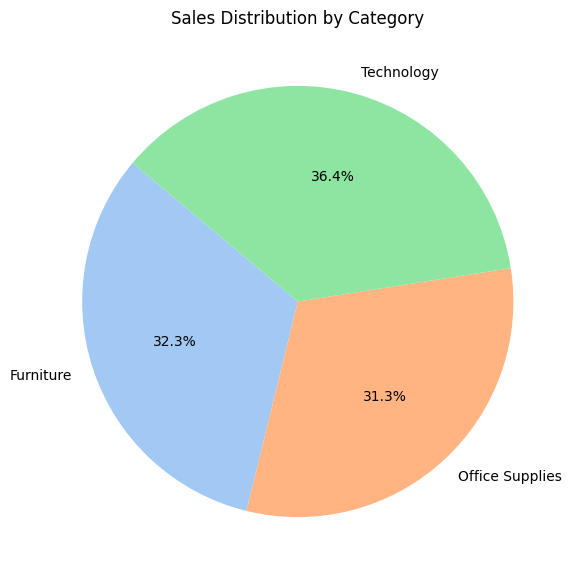

In [30]:
# Sales by Category - Pie Chart
# -----------------------------
category_sales = df.groupby('Category')['Sales'].sum()
plt.figure(figsize=(7,7))
plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Sales Distribution by Category')
plt.show()

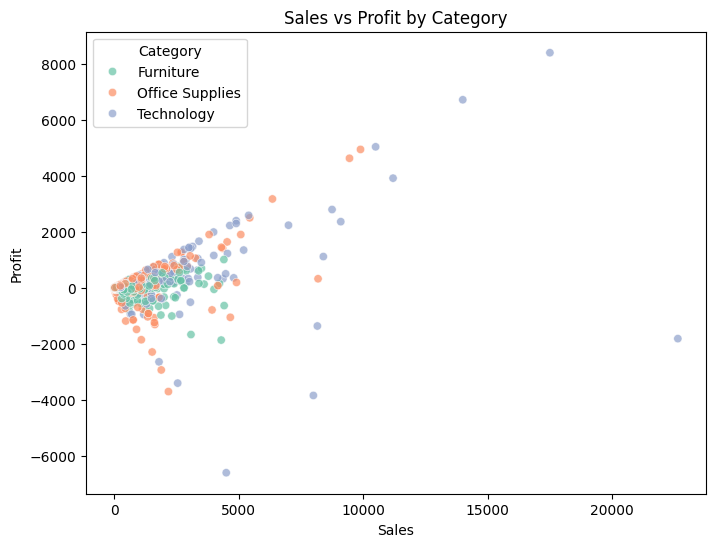

In [31]:
# Sales vs Profit - Scatter Plot
# -----------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category', palette='Set2', alpha=0.7)
plt.title('Sales vs Profit by Category')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()

C:\Users\anu52\AppData\Local\Temp\ipykernel_20468\2042954968.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subcat_quantity.values, y=subcat_quantity.index, palette='coolwarm')


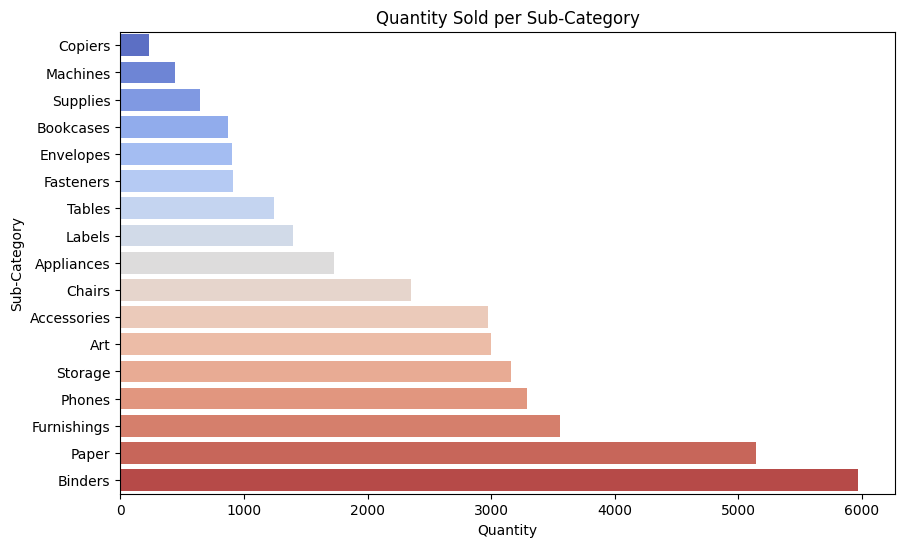

In [32]:
# Quantity Sold per Sub-Category - Horizontal Bar Plot
# -----------------------------
subcat_quantity = df.groupby('Sub-Category')['Quantity'].sum().sort_values()
plt.figure(figsize=(10,6))
sns.barplot(x=subcat_quantity.values, y=subcat_quantity.index, palette='coolwarm')
plt.title('Quantity Sold per Sub-Category')
plt.xlabel('Quantity')
plt.ylabel('Sub-Category')
plt.show()

C:\Users\anu52\AppData\Local\Temp\ipykernel_20468\3279267179.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='Profit', palette='Set3')


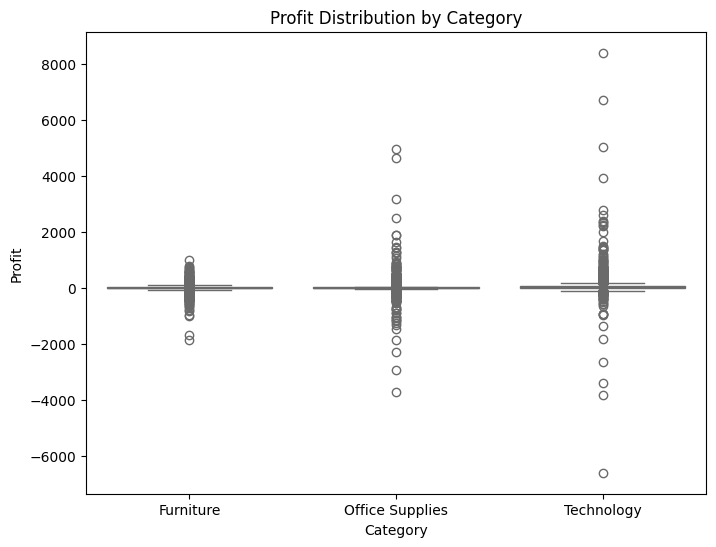

In [33]:
# Discount vs Profit - Box Plot
# -----------------------------
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='Category', y='Profit', palette='Set3')
plt.title('Profit Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

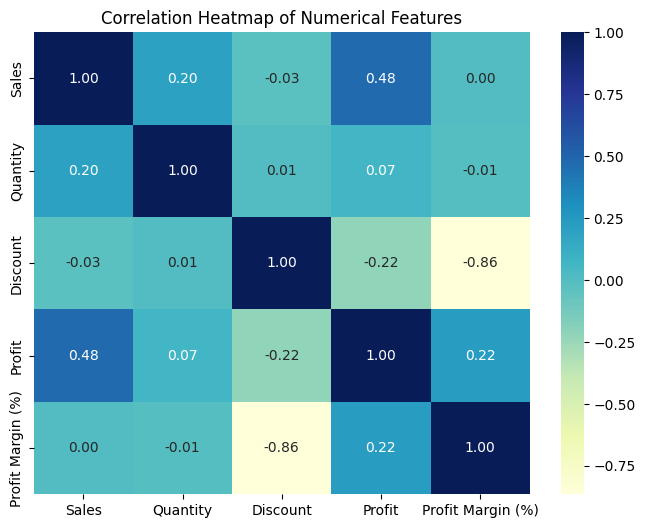

In [35]:
# Heatmap of Correlation
# -----------------------------
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

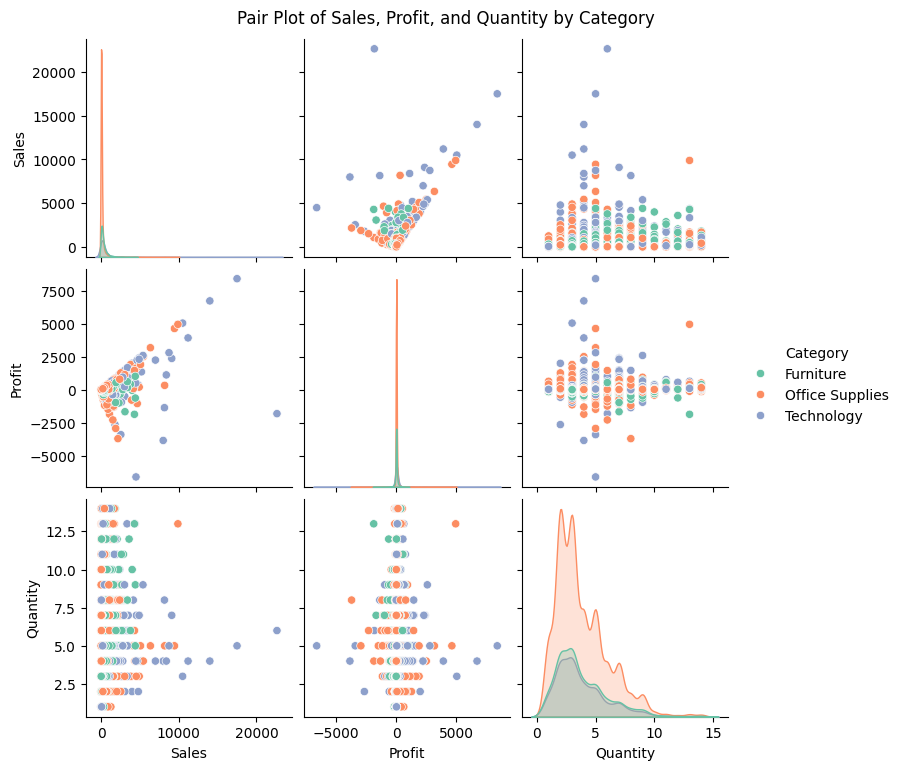

In [36]:
# Pair Plot for Sales, Profit, Quantity
# -----------------------------
sns.pairplot(df[['Sales', 'Profit', 'Quantity', 'Category']], hue='Category', palette='Set2')
plt.suptitle('Pair Plot of Sales, Profit, and Quantity by Category', y=1.02)
plt.show()

C:\Users\anu52\AppData\Local\Temp\ipykernel_20468\4246749578.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Ship Mode', palette='pastel')


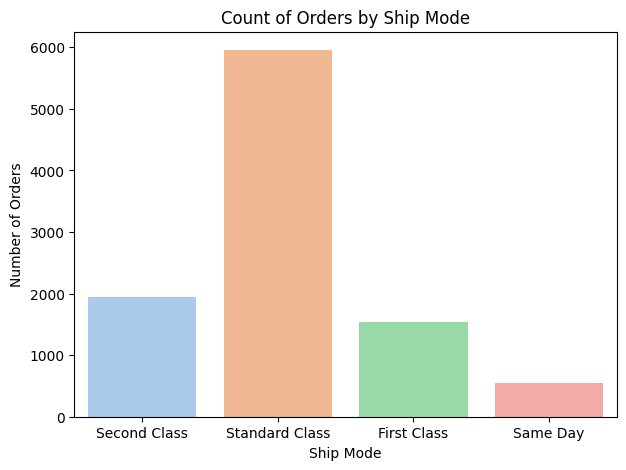

In [37]:
# Count Plot of Ship Mode
# -----------------------------
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Ship Mode', palette='pastel')
plt.title('Count of Orders by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Number of Orders')
plt.show()

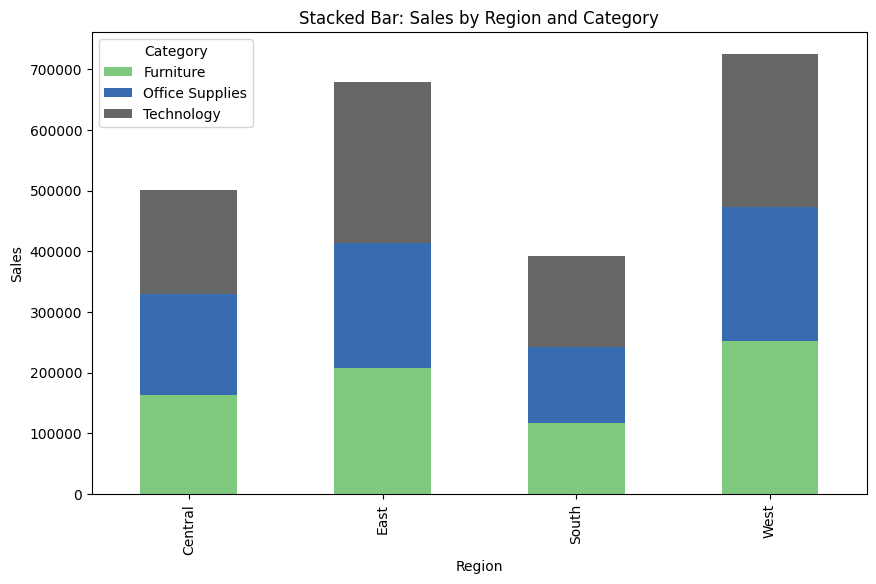

In [38]:
# Stacked Bar Plot - Sales by Region and Category
# -----------------------------
sales_region_category = df.pivot_table(values='Sales', index='Region', columns='Category', aggfunc='sum')
sales_region_category.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Accent')
plt.title('Stacked Bar: Sales by Region and Category')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.legend(title='Category')
plt.show()

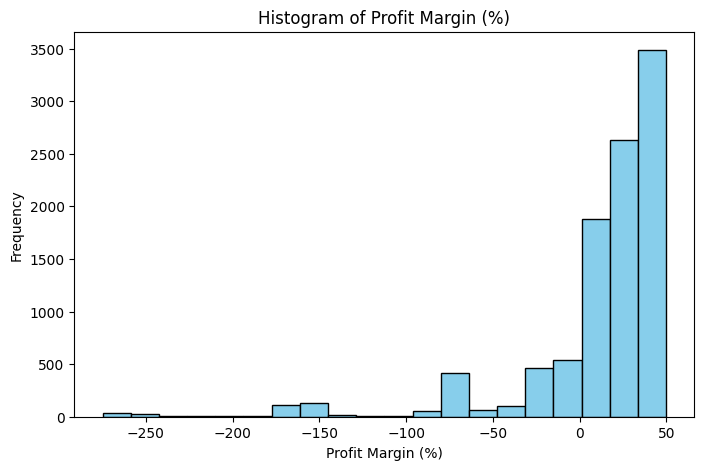

In [39]:
# Histogram of Profit Margin
# -----------------------------
plt.figure(figsize=(8,5))
plt.hist(df['Profit Margin (%)'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Profit Margin (%)')
plt.xlabel('Profit Margin (%)')
plt.ylabel('Frequency')
plt.show()

**Conclusions from Sales Analysis and Visualizations**

1. **Overall Metrics:**

   * Total sales and profit indicate the store's overall revenue generation capability.
   * Average sale per transaction and average profit per transaction show the typical performance per order.
   * Total quantity sold highlights the store’s volume of transactions.

2. **Regional Performance:**

   * Certain regions outperform others in total sales and profit, which can guide strategic focus.
   * Top-performing region (by sales) can be targeted for special promotions or expansion.

3. **Category and Segment Analysis:**

   * Categories like `Technology` or `Furniture` may generate higher sales than others.
   * Segment-wise analysis reveals which customer segments contribute most to revenue, guiding marketing efforts.

4. **Top Products and Customers:**

   * Identifying top-selling products helps in inventory planning and promotions.
   * Knowing top customers aids in loyalty programs and targeted sales strategies.

5. **Profitability Analysis:**

   * Profit margin analysis shows which categories or products are most profitable.
   * Average profit margin provides insight into overall efficiency of sales.

6. **Correlation Analysis:**

   * Strong positive correlation between Sales and Profit confirms higher sales generally lead to higher profit.
   * Other correlations, like Quantity vs. Profit, may highlight operational insights.

7. **Visualizations Insights:**

   * **Bar Plot (Sales by Region):** Shows which regions generate the most revenue.
   * **Pie Chart (Sales by Category):** Highlights the contribution of each category to total sales.
   * **Scatter Plot (Sales vs Profit):** Reveals relationship and variance of profit relative to sales across categories.
   * **Horizontal Bar Plot (Quantity by Sub-Category):** Identifies which sub-categories sell the most units.
   * **Box Plot (Profit by Category):** Shows spread and outliers in profit distribution among categories.
   * **Heatmap:** Displays correlations among numerical features, helping to detect strong relationships.
   * **Pair Plot:** Visualizes relationships between Sales, Profit, and Quantity and category influence.
   * **Count Plot (Ship Mode):** Highlights the most popular shipping modes.
   * **Stacked Bar Plot (Sales by Region and Category):** Shows contribution of each category within each region.
   * **Histogram (Profit Margin):** Shows the distribution and frequency of profit margins across all orders.

**Overall Conclusion:**
The sales analysis provides comprehensive insights into performance by region, category, sub-category, and customer segment. Visualizations reinforce these insights and can guide strategic decisions such as inventory management, promotions, targeted marketing, and operational improvements to maximize profit and sales efficiency.